# Notebook 4: Data Preprocessing for Topic Modelling

## Purpose
Filter to **Negative** reviews only and re-preprocess with a **topic-specific** stopword list.

## Input
`kfc_tp_sentiment_labelled_full.csv` (from Notebook 3)

## Output
- `kfc_tp_negative_reviews.csv`
- `wordcloud_negative_reviews.png`

## Step 0 - Import Libraries

In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
print("Libraries loaded.")

Libraries loaded.


## Step 1 - Configuration

In [2]:
INPUT_FILE     = "kfc_tp_sentiment_labelled_full.csv"
OUTPUT_FILE    = "kfc_tp_negative_reviews.csv"
WORDCLOUD_FILE = "wordcloud_negative_reviews.png"

## Step 2 - Topic Modelling Stopwords

Removes fast-food generics that would dominate every topic.

In [3]:
TOPIC_STOPWORDS = set(stopwords.words("english")).union({
    "kfc", "kentucky", "fried",
    "drive", "thru", "fast", "food", "order", "ordered", "restaurant",
    "meal", "staff", "location", "customer", "service", "place", "menu",
    "eat", "eating", "ate", "review", "experience", "visit", "visited",
    "store", "branch", "delivery", "deliveroo", "uber",
    "got", "get", "could", "also", "like", "do", "does", "did",
    "have", "has", "having", "be", "was", "been", "had", "make",
    "go", "going", "went", "come", "came",
    "im", "dont", "didnt", "theyll", "youre", "ive", "theyre",
    "thats", "yeah", "lol", "u", "us", "cant", "wont", "isnt",
    "time", "now", "then", "there", "when", "day", "year", "today",
    "always", "ago", "last", "still", "just", "even",
    "they", "them", "you", "me", "my", "he", "she", "we", "him",
    "her", "our", "ours", "yours", "theirs", "their", "i",
    "the", "a", "an", "this", "that", "these", "those", "its",
    "to", "of", "in", "on", "at", "from", "with", "about", "for",
    "and", "but", "or", "if", "as", "so", "because", "though",
    "what", "which", "who", "whom", "whose", "how", "where", "why",
    "is", "are", "am", "was", "were", "will", "would", "can",
    "could", "should", "shall",
    "really", "much", "actually", "every", "everything",
    "one", "thing", "not", "people", "said", "say", "way",
    "something", "back", "new", "know", "think", "see", "need",
    "want", "used", "use", "work",
})
print(f"Topic stopwords: {len(TOPIC_STOPWORDS)} words")

Topic stopwords: 288 words


## Step 3 - Load and Filter to Negative Only

In [4]:
df = pd.read_csv(INPUT_FILE)
print(f"Full dataset: {len(df)}")
print(df["Sentiment"].value_counts())

df_neg = df[df["Sentiment"] == "Negative"].copy()
print(f"\nNegative reviews: {len(df_neg)}")

Full dataset: 200
Sentiment
Negative    139
Positive     59
Neutral       2
Name: count, dtype: int64

Negative reviews: 139


## Step 4 - Preprocess for Topic Modelling

In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_for_topics(text):
    lemmatizer = WordNetLemmatizer()
    cleaned = clean_text(text)
    tokens = cleaned.split()
    tokens = [t for t in tokens if t not in TOPIC_STOPWORDS and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df_neg["Tokenised_Review"] = df_neg["Review Text"].apply(preprocess_for_topics)
before = len(df_neg)
df_neg = df_neg[df_neg["Tokenised_Review"].str.strip().astype(bool)]
print(f"Removed {before - len(df_neg)} empty rows")
print(f"Final: {len(df_neg)} reviews")

Removed 0 empty rows
Final: 139 reviews


## Step 5 - Word Cloud

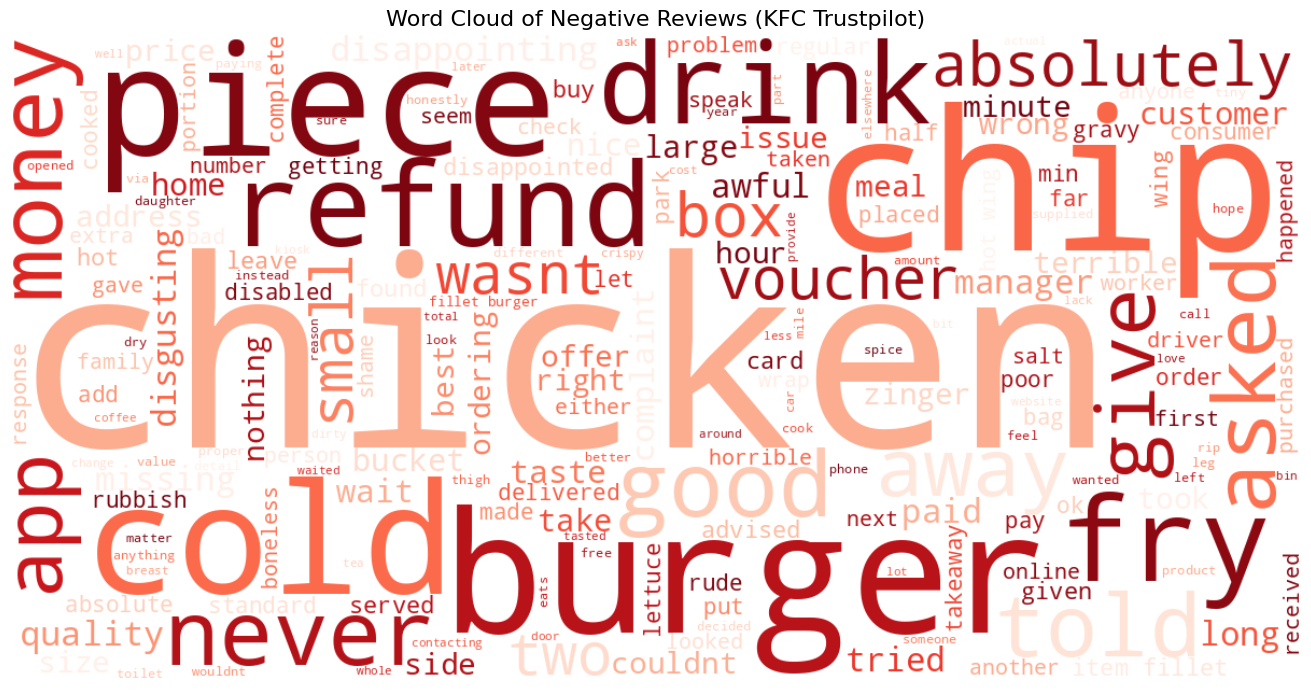

In [6]:
wc = WordCloud(width=1200, height=600, background_color="white",
               max_words=200, colormap="Reds").generate(" ".join(df_neg["Tokenised_Review"]))

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation="bilinear")
plt.title("Word Cloud of Negative Reviews (KFC Trustpilot)", fontsize=16)
plt.axis("off"); plt.tight_layout()
plt.savefig(WORDCLOUD_FILE, dpi=150)
plt.show()

## Step 6 - Save

In [7]:
df_neg.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")
print(f"Saved: {OUTPUT_FILE}")
print(f"Negative reviews: {len(df_neg)}")

Saved: kfc_tp_negative_reviews.csv
Negative reviews: 139
